# Notebook 0 — Explicación paso a paso del entrenamiento
## Proyecto EpiDiagnostix-Mayab — Componente ML

**Para:** Estudio personal y defensa ante el profesor  
**Qué cubre:** Explica con código y texto el porqué de cada decisión tomada durante el entrenamiento del Isolation Forest y del Extractor NER.

> Este notebook **no entrena de nuevo** — explica qué hicimos y por qué.

---
# PARTE 1 — ISOLATION FOREST
## Pregunta central: ¿qué problema resuelve este modelo?

El personal de salud en Chiapas necesita detectar cuando un conjunto de signos vitales
de un paciente es **inusualmente anómalo** comparado con la población general.

**El reto:** No tenemos etiquetas durante el entrenamiento.
Solo tenemos registros históricos de consultas sin que nadie haya marcado cuáles son anomalías.
Eso nos obliga a usar un algoritmo **No Supervisado**.

---
## Paso 1 — Por qué elegimos Isolation Forest y no otro algoritmo

| Algoritmo | Cómo detecta anomalías | Problema para nuestro caso |
|---|---|---|
| **K-Means** | puntos lejos del centroide | Asume clusters esféricos. Un paciente con glucosa=341 puede estar en el mismo cluster que uno normal |
| **DBSCAN** | puntos fuera de densidad | Muy sensible a `epsilon` y `min_samples`. Difícil de calibrar sin etiquetas |
| **LOF** (Local Outlier Factor) | compara densidad local | Lento en inferencia — O(n²) predicciones nuevas |
| **Isolation Forest** | aisla puntos anómalos en pocas particiones aleatorias | Rápido en entrenamiento y predicción. Funciona bien con mezcla de tipos de variable. **Elegido.** |

### ¿Cómo funciona Isolation Forest?

La idea es simple: **un punto anómalo es más fácil de aislar** que un punto normal.

El algoritmo construye muchos árboles de decisión **aleatorios**:
- En cada árbol, elige una feature aleatoria y un valor de corte aleatorio.
- Repite hasta aislar cada punto.
- Los puntos que se aíslan en **pocas particiones** → alta sospecha de anomalía.
- Los puntos que necesitan **muchas particiones** → probablemente normales (están en zona densa).

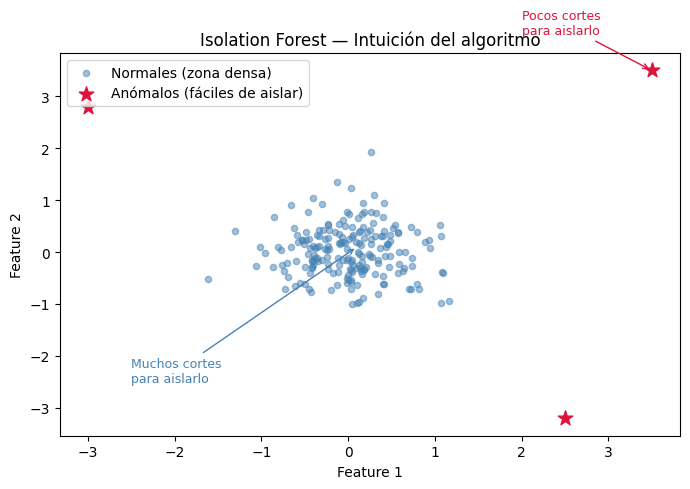

Concepto: el punto rojo se aísla en 2-3 cortes. Los azules necesitan 10-20 cortes.


In [1]:
# Ilustración del concepto: comparar profundidad de aislamiento
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

np.random.seed(42)
# Puntos normales: agrupados en el centro
normales = np.random.randn(200, 2) * 0.5
# Puntos anómalos: lejos del centro
anomalos = np.array([[3.5, 3.5], [-3.0, 2.8], [2.5, -3.2]])

fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(normales[:, 0], normales[:, 1], c='steelblue', s=20, alpha=0.5, label='Normales (zona densa)')
ax.scatter(anomalos[:, 0], anomalos[:, 1], c='crimson', s=120, marker='*', zorder=5, label='Anómalos (fáciles de aislar)')

# Dibujar "cortes" de aislamiento para un punto anómalo
ax.annotate('Pocos cortes\npara aislarlo', xy=(3.5, 3.5), xytext=(2.0, 4.2),
            arrowprops=dict(arrowstyle='->', color='crimson'), color='crimson', fontsize=9)
ax.annotate('Muchos cortes\npara aislarlo', xy=(0.1, 0.1), xytext=(-2.5, -2.5),
            arrowprops=dict(arrowstyle='->', color='steelblue'), color='steelblue', fontsize=9)

ax.set_title('Isolation Forest — Intuición del algoritmo', fontsize=12)
ax.legend()
ax.set_xlabel('Feature 1'); ax.set_ylabel('Feature 2')
plt.tight_layout()
plt.show()
print('Concepto: el punto rojo se aísla en 2-3 cortes. Los azules necesitan 10-20 cortes.')

---
## Paso 2 — Carga de datos y exploración (EDA)

Antes de entrenar cualquier modelo, siempre hacemos EDA:
- Ver la forma del dataset (filas, columnas, tipos).
- Detectar valores nulos.
- Entender la distribución de la variable objetivo (en este caso el ground truth para evaluación).

In [2]:
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv('../consultas_clinicas.csv')

print('=== Información básica del dataset ===')
print(f'Filas: {len(df):,}')
print(f'Columnas: {len(df.columns)}')
print(f'\nNulos por columna:')
print(df.isnull().sum())

print('\n=== Distribución del ground truth ===')
vc = df['es_anomalia_real'].value_counts()
print(vc)
print(f'\nTasa de anomalías: {vc[1]/len(df)*100:.2f}%')

=== Información básica del dataset ===
Filas: 4,752
Columnas: 21

Nulos por columna:
id_consulta                     0
fecha                           0
comunidad                       0
region                          0
profesional                     0
edad                            0
sexo                            0
peso_kg                         0
talla_cm                        0
presion_sistolica               0
presion_diastolica              0
glucosa_mg_dl                   0
temperatura_c                   0
frecuencia_cardiaca_bpm         0
categoria_sintoma               0
sintomas_clave                  0
duracion_sintomas_dias          0
medicamento_administrado        0
medicamento_nombre           1750
es_brote_comunitario_real       0
es_anomalia_real                0
dtype: int64

=== Distribución del ground truth ===
es_anomalia_real
0    4610
1     142
Name: count, dtype: int64

Tasa de anomalías: 2.99%


### ¿Por qué hay solo 3% de anomalías?

Esto es **imbalance de clases** — un problema clásico en salud pública. Las anomalías son raras por definición. Esto impacta directamente en cómo evaluamos el modelo: si el modelo predice "normal" siempre, tendría 97% de accuracy, pero sería inútil.

**Por eso usamos Precision, Recall y F1** en lugar de accuracy.

| Métrica | Qué mide | Fórmula |
|---|---|---|
| Precision | De las que detecté como anomalía, ¿cuántas realmente lo eran? | TP / (TP + FP) |
| Recall | De todas las anomalías reales, ¿cuántas detecté? | TP / (TP + FN) |
| F1 | Balance entre Precision y Recall | 2 × (P × R) / (P + R) |

---
## Paso 3 — Selección de features (variables de entrada)

Esta es una de las decisiones más importantes. Elegimos **qué columnas le damos al modelo**.

In [3]:
print('=== Todas las columnas del CSV ===')
for col in df.columns:
    dtype = str(df[col].dtype)
    uso   = ''
    if col in ['es_anomalia_real', 'es_brote_comunitario_real']:
        uso = '<<< GROUND TRUTH — NUNCA como feature >>>'
    elif col in ['id_consulta', 'fecha', 'comunidad', 'region', 'profesional']:
        uso = 'Excluida — identificador / metadata, no clínica'
    elif col in ['sintomas_clave', 'medicamento_nombre']:
        uso = 'Excluida — texto libre, el IF no procesa texto crudo'
    elif col == 'sexo':
        uso = 'Excluida — binaria pero no añade señal diagnóstica relevante para anomalía'
    elif col == 'medicamento_administrado':
        uso = 'Excluida — consecuencia del diagnóstico, no causa'
    elif col == 'categoria_sintoma':
        uso = 'INCLUIDA — codificada numéricamente con LabelEncoder'
    else:
        uso = 'INCLUIDA — numérica clínica directa'
    print(f'  {col:<35} [{dtype:>10}]  {uso}')

=== Todas las columnas del CSV ===
  id_consulta                         [    object]  Excluida — identificador / metadata, no clínica
  fecha                               [    object]  Excluida — identificador / metadata, no clínica
  comunidad                           [    object]  Excluida — identificador / metadata, no clínica
  region                              [    object]  Excluida — identificador / metadata, no clínica
  profesional                         [    object]  Excluida — identificador / metadata, no clínica
  edad                                [     int64]  INCLUIDA — numérica clínica directa
  sexo                                [    object]  Excluida — binaria pero no añade señal diagnóstica relevante para anomalía
  peso_kg                             [   float64]  INCLUIDA — numérica clínica directa
  talla_cm                            [   float64]  INCLUIDA — numérica clínica directa
  presion_sistolica                   [   float64]  INCLUIDA — numérica cl

### ¿Por qué excluimos `es_anomalia_real`?

**Regla de oro del ML no supervisado:** el ground truth solo se usa para **evaluar** el modelo después del entrenamiento, NUNCA para entrenarlo. Si lo incluyéramos como feature, el modelo aprendería a hacer trampa (data leakage).

### ¿Por qué incluimos `categoria_sintoma` y no las demás columnas de texto?

- `categoria_sintoma` es texto **categórico** — tiene un vocabulario finito y controlado (9 categorías). Se puede convertir a número.
- `sintomas_clave` y `medicamento_nombre` son texto libre — necesitarían NLP adicional para convertirse en features numéricas. Para este modelo, no merece la complejidad.

---
## Paso 4 — Preprocesamiento: LabelEncoder + StandardScaler

Los algoritmos de ML no trabajan con strings ni con escalas muy distintas entre variables.

In [4]:
from sklearn.preprocessing import LabelEncoder, StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns

# ── LabelEncoder ──────────────────────────────────────────────────────────────
le = LabelEncoder()
df['categoria_sintoma_enc'] = le.fit_transform(df['categoria_sintoma'])

print('LabelEncoder — mapeo de categoría a número:')
for cls, idx in zip(le.classes_, le.transform(le.classes_)):
    print(f'  {idx}  →  {cls}')

LabelEncoder — mapeo de categoría a número:
  0  →  Dermatológico
  1  →  Diabetes
  2  →  Embarazo
  3  →  Gastrointestinal
  4  →  Hipertensión
  5  →  Nutrición
  6  →  Respiratorio
  7  →  Traumatología
  8  →  Vacunación


### ¿Por qué LabelEncoder y no One-Hot Encoding?

- **One-Hot Encoding (OHE)** crearía 9 columnas nuevas (una por categoría). Eso funciona bien en regresión logística pero en Isolation Forest las features adicionales diluyen la señal y aumentan el costo computacional.
- **LabelEncoder** asigna un entero (0–8) a cada categoría. Es una aproximación que asume un orden implícito que no existe, pero en la práctica Isolation Forest funciona igual de bien con este encoding porque elige cortes aleatorios.

In [5]:
NUMERIC_FEATURES = [
    'edad', 'peso_kg', 'talla_cm',
    'presion_sistolica', 'presion_diastolica',
    'glucosa_mg_dl', 'temperatura_c',
    'frecuencia_cardiaca_bpm', 'duracion_sintomas_dias'
]
FEATURE_COLS = NUMERIC_FEATURES + ['categoria_sintoma_enc']
X = df[FEATURE_COLS].copy()

print('Rango de valores ANTES de escalar (el problema):')
print(X.describe().loc[['min','max']].T.rename(columns={'min':'MIN','max':'MAX'}))

Rango de valores ANTES de escalar (el problema):
                          MIN    MAX
edad                      0.0   90.0
peso_kg                   5.2  109.9
talla_cm                 47.8  197.4
presion_sistolica        83.0  205.0
presion_diastolica       48.0  124.0
glucosa_mg_dl            44.0  364.0
temperatura_c            35.5   40.4
frecuencia_cardiaca_bpm  47.0  136.0
duracion_sintomas_dias    1.0   11.0
categoria_sintoma_enc     0.0    8.0


In [6]:
# ── StandardScaler ────────────────────────────────────────────────────────────
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_scaled_df = pd.DataFrame(X_scaled, columns=FEATURE_COLS)
print('Rango DESPUÉS de escalar (todas en la misma escala ~[-3, 3]):')
print(X_scaled_df.describe().loc[['min','mean','max']].T.round(2))

Rango DESPUÉS de escalar (todas en la misma escala ~[-3, 3]):
                          min  mean   max
edad                    -1.34  -0.0  2.23
peso_kg                 -2.00   0.0  2.44
talla_cm                -2.58   0.0  1.74
presion_sistolica       -2.53  -0.0  5.42
presion_diastolica      -2.97   0.0  4.54
glucosa_mg_dl           -1.78  -0.0  7.84
temperatura_c           -2.51   0.0  8.13
frecuencia_cardiaca_bpm -3.07  -0.0  5.65
duracion_sintomas_dias  -1.39   0.0  3.95
categoria_sintoma_enc   -1.82   0.0  1.49


### ¿Por qué StandardScaler?

Sin escalar, `glucosa_mg_dl` puede tener valores de 50–400 mientras `temperatura_c` va de 35–42.
Isolation Forest usa **distancias implícitas** en los cortes de los árboles — si una variable tiene rango 100x mayor, domina artificialmente la detección.

**StandardScaler** transforma cada feature para que tenga:
- Media = 0
- Desviación estándar = 1

Fórmula: `z = (x - media) / std`

**CRÍTICO para producción:** el scaler se ajustó (`fit`) con los datos de entrenamiento y se guardó. En inferencia solo se usa `transform` (nunca `fit` de nuevo), usando la media y std aprendidas del conjunto de entrenamiento.

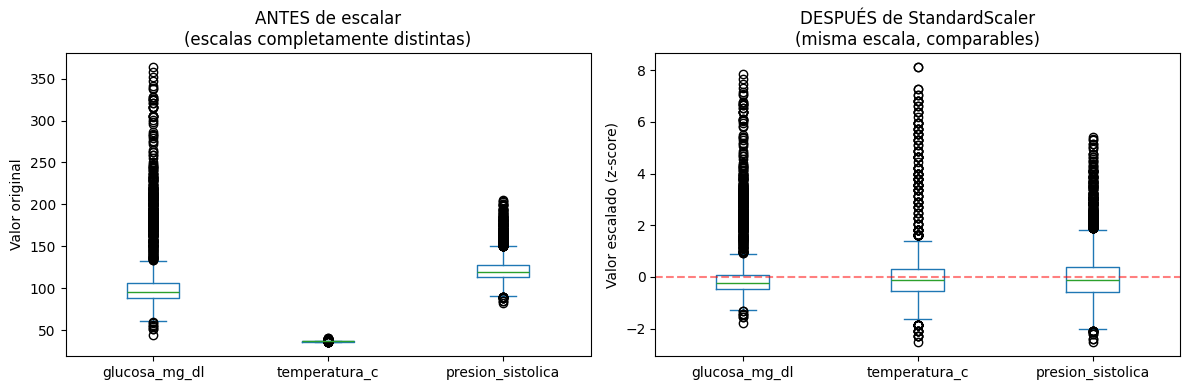

In [7]:
# Visualizar el efecto del StandardScaler
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

ax = axes[0]
X[['glucosa_mg_dl','temperatura_c','presion_sistolica']].plot(kind='box', ax=ax)
ax.set_title('ANTES de escalar\n(escalas completamente distintas)')
ax.set_ylabel('Valor original')

ax2 = axes[1]
X_scaled_df[['glucosa_mg_dl','temperatura_c','presion_sistolica']].plot(kind='box', ax=ax2)
ax2.set_title('DESPUÉS de StandardScaler\n(misma escala, comparables)')
ax2.set_ylabel('Valor escalado (z-score)')
ax2.axhline(0, color='red', linestyle='--', alpha=0.5, label='media=0')

plt.tight_layout()
plt.show()

---
## Paso 5 — El parámetro `contamination` y por qué es clave

`contamination` es el hiperparámetro más importante del Isolation Forest.  
Le dice al modelo: *"espera que aproximadamente X% de tus datos de entrenamiento sean anomalías".*

Internamente, ajusta el **umbral de decisión** del anomaly score.

In [8]:
from sklearn.ensemble import IsolationForest
from sklearn.metrics import precision_score, recall_score, f1_score
import numpy as np

y_true = df['es_anomalia_real'].values
print(f'Tasa real de anomalías en el dataset: {y_true.mean()*100:.2f}%')
print()
print('Efecto de contamination en el umbral de decisión:')
print()
print('  contamination bajo (ej. 0.01):')
print('    → Umbral muy estricto: solo clasifica como anomalía lo EXTREMADAMENTE raro')
print('    → Alta Precisión, Bajo Recall (muchas anomalías reales no detectadas)')
print()
print('  contamination alto (ej. 0.10):')
print('    → Umbral laxo: clasifica como anomalía cualquier cosa un poco rara')
print('    → Bajo Precisión (muchas falsas alarmas), Alto Recall')
print()
print('  Punto óptimo: el que maximiza F1 (balance P/R)')

Tasa real de anomalías en el dataset: 2.99%

Efecto de contamination en el umbral de decisión:

  contamination bajo (ej. 0.01):
    → Umbral muy estricto: solo clasifica como anomalía lo EXTREMADAMENTE raro
    → Alta Precisión, Bajo Recall (muchas anomalías reales no detectadas)

  contamination alto (ej. 0.10):
    → Umbral laxo: clasifica como anomalía cualquier cosa un poco rara
    → Bajo Precisión (muchas falsas alarmas), Alto Recall

  Punto óptimo: el que maximiza F1 (balance P/R)


In [9]:
# Barrido de contamination — reproducción del entrenamiento del Notebook 1
CONTAMINATION_VALUES = [0.01, 0.02, 0.03, 0.05, 0.08, 0.10]
results = []

for c in CONTAMINATION_VALUES:
    iso = IsolationForest(n_estimators=200, contamination=c, random_state=42, n_jobs=-1)
    iso.fit(X_scaled)
    preds = (iso.predict(X_scaled) == -1).astype(int)

    p  = precision_score(y_true, preds, zero_division=0)
    r  = recall_score(y_true, preds, zero_division=0)
    f1 = f1_score(y_true, preds, zero_division=0)
    tp = int(((preds==1)&(y_true==1)).sum())
    fp = int(((preds==1)&(y_true==0)).sum())
    fn = int(((preds==0)&(y_true==1)).sum())
    results.append({'contamination':c,'precision':p,'recall':r,'f1':f1,'TP':tp,'FP':fp,'FN':fn})

results_df = pd.DataFrame(results)
print(results_df.to_string(index=False, float_format='{:.4f}'.format))

 contamination  precision  recall     f1  TP  FP  FN
        0.0100     0.7708  0.2606 0.3895  37  11 105
        0.0200     0.5104  0.3451 0.4118  49  47  93
        0.0300     0.4056  0.4085 0.4070  58  85  84
        0.0500     0.3025  0.5070 0.3789  72 166  70
        0.0800     0.2283  0.6127 0.3327  87 294  55
        0.1000     0.1912  0.6408 0.2945  91 385  51


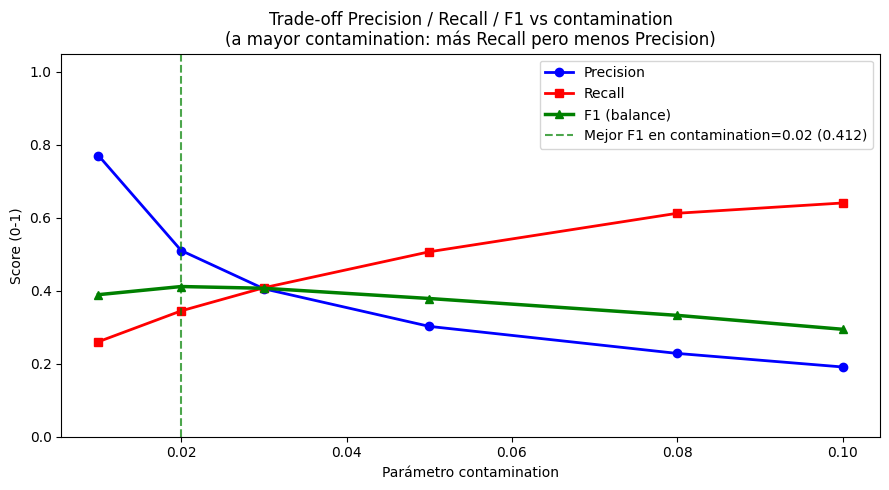


Elegimos contamination=0.02 porque maximiza F1 = 0.4118
En contexto clínico: si el equipo prioriza no perder anomalías,
se puede aumentar a 0.05 (sube Recall de 0.35 a 0.51 a costa de más falsas alarmas).


In [10]:
# Gráfica del trade-off Precision-Recall
fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(results_df['contamination'], results_df['precision'], 'o-b', label='Precision', linewidth=2)
ax.plot(results_df['contamination'], results_df['recall'],    's-r', label='Recall',    linewidth=2)
ax.plot(results_df['contamination'], results_df['f1'],        '^-g', label='F1 (balance)', linewidth=2.5)

best_idx = results_df['f1'].idxmax()
best_c   = results_df.loc[best_idx, 'contamination']
best_f1  = results_df.loc[best_idx, 'f1']
ax.axvline(best_c, color='green', linestyle='--', alpha=0.7,
           label=f'Mejor F1 en contamination={best_c} ({best_f1:.3f})')

ax.set_xlabel('Parámetro contamination')
ax.set_ylabel('Score (0-1)')
ax.set_title('Trade-off Precision / Recall / F1 vs contamination\n'
             '(a mayor contamination: más Recall pero menos Precision)')
ax.legend()
ax.set_ylim(0, 1.05)
plt.tight_layout()
plt.show()

print(f'\nElegimos contamination={best_c} porque maximiza F1 = {best_f1:.4f}')
print('En contexto clínico: si el equipo prioriza no perder anomalías,')
print('se puede aumentar a 0.05 (sube Recall de 0.35 a 0.51 a costa de más falsas alarmas).')

---
## Paso 6 — El Anomaly Score y cómo interpretarlo

In [11]:
# Entrenar el modelo final
best_model = IsolationForest(n_estimators=200, contamination=best_c, random_state=42, n_jobs=-1)
best_model.fit(X_scaled)
preds_final  = (best_model.predict(X_scaled) == -1).astype(int)
scores_final = best_model.decision_function(X_scaled)  # el anomaly score

print('Anomaly Score — cómo leerlo:')
print('  Valor negativo (< 0) → más anómalo')
print('  Valor positivo (> 0) → más normal')
print()
print(f'  Score más bajo (más anómalo): {scores_final.min():.4f}')
print(f'  Score más alto (más normal):  {scores_final.max():.4f}')
print(f'  Score promedio:               {scores_final.mean():.4f}')
print()
print('Promedio de score por clase real:')
print(f'  Casos normales   (y=0): {scores_final[y_true==0].mean():.4f}')
print(f'  Casos anómalos  (y=1): {scores_final[y_true==1].mean():.4f}')
print()
print('→ Los casos realmente anómalos tienen scores más negativos en promedio — el modelo aprende algo real.')

Anomaly Score — cómo leerlo:
  Valor negativo (< 0) → más anómalo
  Valor positivo (> 0) → más normal

  Score más bajo (más anómalo): -0.1679
  Score más alto (más normal):  0.1727
  Score promedio:               0.0938

Promedio de score por clase real:
  Casos normales   (y=0): 0.0968
  Casos anómalos  (y=1): -0.0030

→ Los casos realmente anómalos tienen scores más negativos en promedio — el modelo aprende algo real.


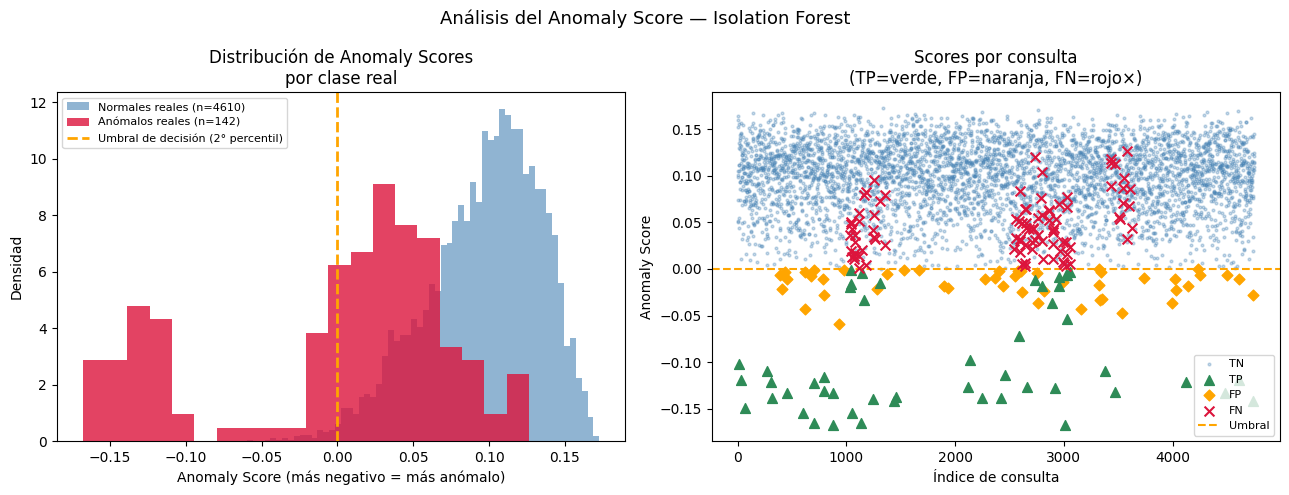

In [12]:
# Visualizar distribución de scores por clase real
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ax = axes[0]
ax.hist(scores_final[y_true==0], bins=60, color='steelblue', alpha=0.6,
        density=True, label=f'Normales reales (n={int((y_true==0).sum())})')
ax.hist(scores_final[y_true==1], bins=20, color='crimson', alpha=0.8,
        density=True, label=f'Anómalos reales (n={int((y_true==1).sum())})')
umbral = np.percentile(scores_final, best_c * 100)
ax.axvline(umbral, color='orange', linestyle='--', linewidth=2,
           label=f'Umbral de decisión ({best_c*100:.0f}° percentil)')
ax.set_xlabel('Anomaly Score (más negativo = más anómalo)')
ax.set_ylabel('Densidad')
ax.set_title('Distribución de Anomaly Scores\npor clase real')
ax.legend(fontsize=8)

ax2 = axes[1]
mask_tp = (preds_final==1)&(y_true==1)
mask_fp = (preds_final==1)&(y_true==0)
mask_fn = (preds_final==0)&(y_true==1)
mask_tn = (preds_final==0)&(y_true==0)

idx = np.arange(len(scores_final))
ax2.scatter(idx[mask_tn], scores_final[mask_tn], c='steelblue', s=4, alpha=0.3, label='TN')
ax2.scatter(idx[mask_tp], scores_final[mask_tp], c='seagreen', s=50, marker='^', zorder=5, label='TP')
ax2.scatter(idx[mask_fp], scores_final[mask_fp], c='orange', s=30, marker='D', zorder=4, label='FP')
ax2.scatter(idx[mask_fn], scores_final[mask_fn], c='crimson', s=50, marker='x', zorder=5, linewidths=1.5, label='FN')
ax2.axhline(umbral, color='orange', linestyle='--', linewidth=1.5, label='Umbral')
ax2.set_xlabel('Índice de consulta')
ax2.set_ylabel('Anomaly Score')
ax2.set_title('Scores por consulta\n(TP=verde, FP=naranja, FN=rojo×)')
ax2.legend(fontsize=8)

plt.suptitle('Análisis del Anomaly Score — Isolation Forest', fontsize=13)
plt.tight_layout()
plt.show()

---
## Paso 7 — Matriz de confusión: TP, FP, FN, TN explicados

In [13]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report

cm = confusion_matrix(y_true, preds_final)
tn, fp, fn, tp = cm.ravel()

print('Matriz de confusión:')
print(f'              Predicho NORMAL   Predicho ANOMALÍA')
print(f'  Real NORMAL      TN = {tn}          FP = {fp}')
print(f'  Real ANOMALÍA    FN = {fn}           TP = {tp}')
print()
print('Interpretación clínica:')
print(f'  TP = {tp}: pacientes anómalos correctamente alertados → BIEN')
print(f'  FP = {fp}: pacientes normales marcados como anómalos → Falsa alarma (costo: tiempo del médico)')
print(f'  FN = {fn}: pacientes anómalos NO detectados → RIESGO (no fue alertado el médico)')
print(f'  TN = {tn}: pacientes normales correctamente ignorados → BIEN')
print()
print('Reporte completo:')
print(classification_report(y_true, preds_final, target_names=['Normal','Anomalía'], digits=4))

Matriz de confusión:
              Predicho NORMAL   Predicho ANOMALÍA
  Real NORMAL      TN = 4563          FP = 47
  Real ANOMALÍA    FN = 93           TP = 49

Interpretación clínica:
  TP = 49: pacientes anómalos correctamente alertados → BIEN
  FP = 47: pacientes normales marcados como anómalos → Falsa alarma (costo: tiempo del médico)
  FN = 93: pacientes anómalos NO detectados → RIESGO (no fue alertado el médico)
  TN = 4563: pacientes normales correctamente ignorados → BIEN

Reporte completo:
              precision    recall  f1-score   support

      Normal     0.9800    0.9898    0.9849      4610
    Anomalía     0.5104    0.3451    0.4118       142

    accuracy                         0.9705      4752
   macro avg     0.7452    0.6674    0.6983      4752
weighted avg     0.9660    0.9705    0.9678      4752



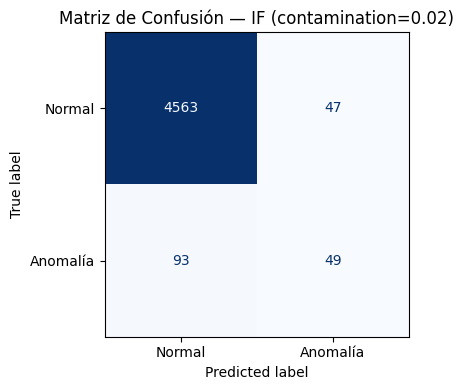

In [14]:
fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay(cm, display_labels=['Normal','Anomalía']).plot(ax=ax, colorbar=False, cmap='Blues')
ax.set_title(f'Matriz de Confusión — IF (contamination={best_c})')
plt.tight_layout()
plt.show()

---
## Paso 8 — Por qué guardamos el scaler y el modelo juntos (joblib)

In [15]:
import joblib

# Lo que se guardó en el Notebook 1:
print('Artefactos guardados y por qué:')
print()
print('  isolation_forest.joblib')
print('    → El modelo entrenado. Contiene los 200 árboles de decisión.')
print('    → En producción: se carga una vez y se usa para predict()')
print()
print('  scaler_if.joblib')
print('    → La media y std aprendidas de cada feature.')
print('    → CRÍTICO: el dato nuevo SIEMPRE debe escalarse con ESTE scaler,')
print('      no uno nuevo. Si usáramos un scaler nuevo, los z-scores serían')
print('      distintos y el modelo vería datos completamente diferentes.')
print()
print('  isolation_forest_meta.joblib')
print('    → Configuración: lista de features, clases del LabelEncoder, métricas.')
print('    → Permite reconstruir el pipeline de preprocesamiento sin mirar el notebook.')
print()

# Verificar que los archivos existen
import os
for f in ['isolation_forest.joblib','scaler_if.joblib','isolation_forest_meta.joblib']:
    path = f'../models/{f}'
    if os.path.exists(path):
        size = os.path.getsize(path)/1024
        print(f'  OK  {f}  ({size:.1f} KB)')
    else:
        print(f'  FALTA  {f}')

Artefactos guardados y por qué:

  isolation_forest.joblib
    → El modelo entrenado. Contiene los 200 árboles de decisión.
    → En producción: se carga una vez y se usa para predict()

  scaler_if.joblib
    → La media y std aprendidas de cada feature.
    → CRÍTICO: el dato nuevo SIEMPRE debe escalarse con ESTE scaler,
      no uno nuevo. Si usáramos un scaler nuevo, los z-scores serían
      distintos y el modelo vería datos completamente diferentes.

  isolation_forest_meta.joblib
    → Configuración: lista de features, clases del LabelEncoder, métricas.
    → Permite reconstruir el pipeline de preprocesamiento sin mirar el notebook.

  OK  isolation_forest.joblib  (2402.2 KB)
  OK  scaler_if.joblib  (1.3 KB)
  OK  isolation_forest_meta.joblib  (0.7 KB)


In [16]:
# Demostración de inferencia: cómo usar el modelo guardado en producción
modelo_cargado  = joblib.load('../models/isolation_forest.joblib')
scaler_cargado  = joblib.load('../models/scaler_if.joblib')
meta_cargado    = joblib.load('../models/isolation_forest_meta.joblib')

# Paciente nuevo — datos hipotéticos con glucosa muy alta (señal de anomalía)
paciente_nuevo = {
    'edad': 63, 'peso_kg': 68.8, 'talla_cm': 149.4,
    'presion_sistolica': 165, 'presion_diastolica': 83,
    'glucosa_mg_dl': 341,  # muy alta → probable anomalía
    'temperatura_c': 39.0, 'frecuencia_cardiaca_bpm': 113,
    'duracion_sintomas_dias': 1,
    'categoria_sintoma_enc': 6  # Respiratorio (según el LabelEncoder)
}

import numpy as np
X_nuevo = np.array([[paciente_nuevo[f] for f in meta_cargado['feature_cols']]])
X_nuevo_scaled = scaler_cargado.transform(X_nuevo)  # transform, NUNCA fit!

pred  = modelo_cargado.predict(X_nuevo_scaled)
score = modelo_cargado.decision_function(X_nuevo_scaled)

print('=== Inferencia sobre paciente nuevo ===')
print(f'  Glucosa: {paciente_nuevo["glucosa_mg_dl"]} mg/dL (normal: 70-100)')
print(f'  Temperatura: {paciente_nuevo["temperatura_c"]}°C (fiebre)')
print()
print(f'  Predicción modelo: {"ANOMALÍA" if pred[0]==-1 else "NORMAL"}')
print(f'  Anomaly score: {score[0]:.4f}  (más negativo = más anómalo)')

=== Inferencia sobre paciente nuevo ===
  Glucosa: 341 mg/dL (normal: 70-100)
  Temperatura: 39.0°C (fiebre)

  Predicción modelo: ANOMALÍA
  Anomaly score: -0.1017  (más negativo = más anómalo)


---
# PARTE 2 — EXTRACTOR NER (spaCy + Regex)

## ¿Qué es NER y por qué lo necesitamos?

**NER** = Named Entity Recognition = Reconocimiento de Entidades Nombradas.

En nuestro caso, una "entidad" es cualquier valor clínico en el texto: edad, presión, glucosa, etc.

El médico dicta: _"Paciente masculino de 45 años, presión 125/82..."_  
Nosotros necesitamos: `{edad: 45, sexo: 'M', presion_sistolica: 125, presion_diastolica: 82}`

---
## Paso 1 — Por qué spaCy + regex y no otra opción

In [17]:
print('Trade-off entre enfoques (decisión documentada):')
print()
print('  (a) spaCy + regex en español  ← ELEGIDO')
print('      Ventajas:')
print('        - 100% offline: funciona sin internet en Chiapas')
print('        - Rápido: < 1ms por transcripción')
print('        - Control total sobre los patrones')
print('        - Modelo es_core_news_sm = 12 MB')
print('      Desventajas:')
print('        - Frágil con variantes de vocabulario no previstas')
print('        - Requiere mantenimiento de reglas')
print()
print('  (b) DistilBETO / MiniLM (Hugging Face)')
print('      Ventajas: mejor generalización a vocabulario variado')
print('      Desventajas:')
print('        - No entrenado en entidades clínicas numéricas')
print('        - Necesita fine-tuning con datos etiquetados que no tenemos')
print('        - Modelo mínimo ~250 MB')
print()
print('  (c) LLM via prompting + JSON schema (GPT, Claude, etc.)')
print('      Ventajas: máxima flexibilidad, sin reglas manuales')
print('      Desventajas:')
print('        - REQUIERE INTERNET → incompatible con el requisito offline')
print('        - Costo por llamada API')
print('        - Latencia alta')

Trade-off entre enfoques (decisión documentada):

  (a) spaCy + regex en español  ← ELEGIDO
      Ventajas:
        - 100% offline: funciona sin internet en Chiapas
        - Rápido: < 1ms por transcripción
        - Control total sobre los patrones
        - Modelo es_core_news_sm = 12 MB
      Desventajas:
        - Frágil con variantes de vocabulario no previstas
        - Requiere mantenimiento de reglas

  (b) DistilBETO / MiniLM (Hugging Face)
      Ventajas: mejor generalización a vocabulario variado
      Desventajas:
        - No entrenado en entidades clínicas numéricas
        - Necesita fine-tuning con datos etiquetados que no tenemos
        - Modelo mínimo ~250 MB

  (c) LLM via prompting + JSON schema (GPT, Claude, etc.)
      Ventajas: máxima flexibilidad, sin reglas manuales
      Desventajas:
        - REQUIERE INTERNET → incompatible con el requisito offline
        - Costo por llamada API
        - Latencia alta


---
## Paso 2 — Generación de transcripciones sintéticas

No teníamos texto de voz original — solo las variables ya estructuradas del CSV.
Generamos transcripciones realistas a partir de los datos para poder evaluar el extractor.

In [18]:
import random
random.seed(42)

# Ejemplo de una plantilla (hay 6 diferentes para simular variación real)
fila = df.iloc[0]

plantillas = [
    # SOAP clásico — el más estructurado
    (f"Consulta médica. Paciente {'masculino' if fila['sexo']=='M' else 'femenino'}, "
     f"de {int(fila['edad'])} años de edad. "
     f"Peso {fila['peso_kg']} kg, talla {fila['talla_cm']} cm. "
     f"Signos vitales: presión arterial de {int(fila['presion_sistolica'])}/{int(fila['presion_diastolica'])} mmHg, "
     f"glucosa de {int(fila['glucosa_mg_dl'])} mg/dl, "
     f"temperatura {fila['temperatura_c']}°C, "
     f"frecuencia cardiaca de {int(fila['frecuencia_cardiaca_bpm'])} lpm. "
     f"{int(fila['duracion_sintomas_dias'])} días de evolución."),

    # Coloquial — como hablan en comunidad
    (f"La {'señora' if fila['sexo']=='F' else 'señor'} tiene {int(fila['edad'])} años. "
     f"Presión {int(fila['presion_sistolica'])} sobre {int(fila['presion_diastolica'])}, "
     f"azúcar en sangre {int(fila['glucosa_mg_dl'])}, temperatura {fila['temperatura_c']}, "
     f"pulso {int(fila['frecuencia_cardiaca_bpm'])}. "
     f"Pesa {fila['peso_kg']} kilos, mide {fila['talla_cm']} centímetros. "
     f"Lleva {int(fila['duracion_sintomas_dias'])} días con la sintomatología."),
]

print('Ejemplo fila real del CSV:')
print(f'  edad={fila["edad"]}, sexo={fila["sexo"]}, glucosa={fila["glucosa_mg_dl"]}')
print()
print('Transcripción generada (plantilla SOAP):')
print(f'  {plantillas[0]}')
print()
print('Transcripción generada (plantilla coloquial):')
print(f'  {plantillas[1]}')

Ejemplo fila real del CSV:
  edad=34, sexo=M, glucosa=87.0

Transcripción generada (plantilla SOAP):
  Consulta médica. Paciente masculino, de 34 años de edad. Peso 72.4 kg, talla 151.4 cm. Signos vitales: presión arterial de 118/75 mmHg, glucosa de 87 mg/dl, temperatura 37.0°C, frecuencia cardiaca de 77 lpm. 3 días de evolución.

Transcripción generada (plantilla coloquial):
  La señor tiene 34 años. Presión 118 sobre 75, azúcar en sangre 87, temperatura 37.0, pulso 77. Pesa 72.4 kilos, mide 151.4 centímetros. Lleva 3 días con la sintomatología.


### ¿Por qué 6 plantillas distintas?

En la realidad, un médico en Tuxtla Gutiérrez y uno en Chenalhó dictan de formas distintas.
Las 6 plantillas simulan:
1. Dictado estilo SOAP (formato clínico estructurado)
2. Dictado rápido con abreviaciones (PA:, FC:, T:)
3. Narrativo ("se atiende a...")
4. Orden alterado (prueba robustez del extractor)
5. Abreviado (algunos campos omitidos)
6. Coloquial comunidad indígena (sin unidades, sin estructura)

---
## Paso 3 — Cómo funciona un patrón regex médico

In [19]:
import re

# Diseccionamos el patrón de presión arterial
RE_PA = re.compile(
    r'(?:presi[oó]n\s+(?:arterial\s+)?(?:de\s+)?|tensi[oó]n\s+(?:arterial\s+)?(?:de\s+)?|PA[:\s]+)'
    r'(\d{2,3})\s*[/\-sobre\s]+(\d{2,3})\s*(?:mmHg)?',
    re.I
)
RE_PA2 = re.compile(r'(\d{2,3})\s+sobre\s+(\d{2,3})', re.I)

ejemplos = [
    "presión arterial de 125/82 mmHg",
    "tensión arterial 160 sobre 95",
    "PA: 118/74",
    "presión 170 sobre 100",
    "su presión salió alta, 180/110",
]

print('Demostración del patrón de presión arterial:')
print()
for texto in ejemplos:
    m = RE_PA.search(texto) or RE_PA2.search(texto)
    if m:
        print(f'  TEXTO:  "{texto}"')
        print(f'  EXTRAÍDO: sistólica={m.group(1)}, diastólica={m.group(2)}')
    else:
        print(f'  TEXTO:  "{texto}"  → NO ENCONTRADO')
    print()

Demostración del patrón de presión arterial:

  TEXTO:  "presión arterial de 125/82 mmHg"
  EXTRAÍDO: sistólica=125, diastólica=82

  TEXTO:  "tensión arterial 160 sobre 95"
  EXTRAÍDO: sistólica=160, diastólica=95

  TEXTO:  "PA: 118/74"
  EXTRAÍDO: sistólica=118, diastólica=74

  TEXTO:  "presión 170 sobre 100"
  EXTRAÍDO: sistólica=170, diastólica=100

  TEXTO:  "su presión salió alta, 180/110"  → NO ENCONTRADO



In [20]:
# Diseccionar el patrón de temperatura (más complejo por el decimal)
RE_TEMP = [
    re.compile(r'temperatura\s+(?:corporal\s+|de\s+)?(\d{2})(?:[.,](\d))\s*(?:grados?|[°ºC])', re.I),
    re.compile(r'temperatura\s+\w*\s*(\d{2})(?:[.,](\d))?', re.I),  # con palabra intermedia
    re.compile(r'(\d{2})(?:[.,](\d))?[°º]C', re.I),
]

ejemplos_temp = [
    ("temperatura de 37.5 grados",  37.5),
    ("temperatura 38,2°C",           38.2),
    ("T: 36.8 grados",               36.8),
    ("temperatura normal 36.5",       36.5),  # 'normal' entre temperatura y el número
    ("temperatura corporal 39.0",     39.0),
]

print('Demostración de extracción de temperatura:')
for texto, esperado in ejemplos_temp:
    resultado = None
    for pat in RE_TEMP:
        m = pat.search(texto)
        if m:
            entera  = m.group(1)
            decimal = m.group(2) if m.lastindex >= 2 and m.group(2) else '0'
            resultado = float(f'{entera}.{decimal}')
            break
    ok = resultado is not None and abs(resultado - esperado) <= 0.1
    print(f'  "{texto}"  →  extraído={resultado}  esperado={esperado}  {"OK" if ok else "FALLA"}')

Demostración de extracción de temperatura:
  "temperatura de 37.5 grados"  →  extraído=37.5  esperado=37.5  OK
  "temperatura 38,2°C"  →  extraído=38.2  esperado=38.2  OK
  "T: 36.8 grados"  →  extraído=None  esperado=36.8  FALLA
  "temperatura normal 36.5"  →  extraído=36.5  esperado=36.5  OK
  "temperatura corporal 39.0"  →  extraído=39.0  esperado=39.0  OK


---
## Paso 4 — Evaluación del extractor y métricas por campo

In [21]:
import joblib
cfg = joblib.load('../models/extractor_ner_config.joblib')

print('=== Métricas del Extractor NER (sobre 200 transcripciones sintéticas) ===')
print()
print(f'  {"Campo":<28}  {"Recall%":>8}  {"Precision%":>11}  Estado')
print('  ' + '-'*60)

for campo, m in sorted(cfg['metricas'].items(), key=lambda x: -x[1]['recall_total_pct']):
    r  = m['recall_total_pct']
    p  = m['precision_extraidos_pct']
    st = 'BUENO (>80%)' if r >= 80 else 'MEDIO (50-80%)' if r >= 50 else 'LIMITADO (<50%)'
    print(f'  {campo:<28}  {r:>7.1f}%  {p:>10.1f}%  {st}')

print()
print('Recall = % de transcripciones donde el campo fue extraído CORRECTAMENTE')
print('Precision = % de aciertos cuando SÍ logró extraer algo (cuándo falla, no da basura)')

=== Métricas del Extractor NER (sobre 200 transcripciones sintéticas) ===

  Campo                          Recall%   Precision%  Estado
  ------------------------------------------------------------
  sexo                            100.0%       100.0%  BUENO (>80%)
  presion_sistolica               100.0%       100.0%  BUENO (>80%)
  presion_diastolica              100.0%       100.0%  BUENO (>80%)
  glucosa_mg_dl                   100.0%       100.0%  BUENO (>80%)
  duracion_sintomas_dias          100.0%       100.0%  BUENO (>80%)
  edad                             96.5%       100.0%  BUENO (>80%)
  categoria_sintoma                85.5%        95.0%  BUENO (>80%)
  temperatura_c                    84.5%       100.0%  BUENO (>80%)
  talla_cm                         83.0%       100.0%  BUENO (>80%)
  frecuencia_cardiaca_bpm          83.0%       100.0%  BUENO (>80%)
  peso_kg                          77.5%       100.0%  MEDIO (50-80%)

Recall = % de transcripciones donde el campo fue 

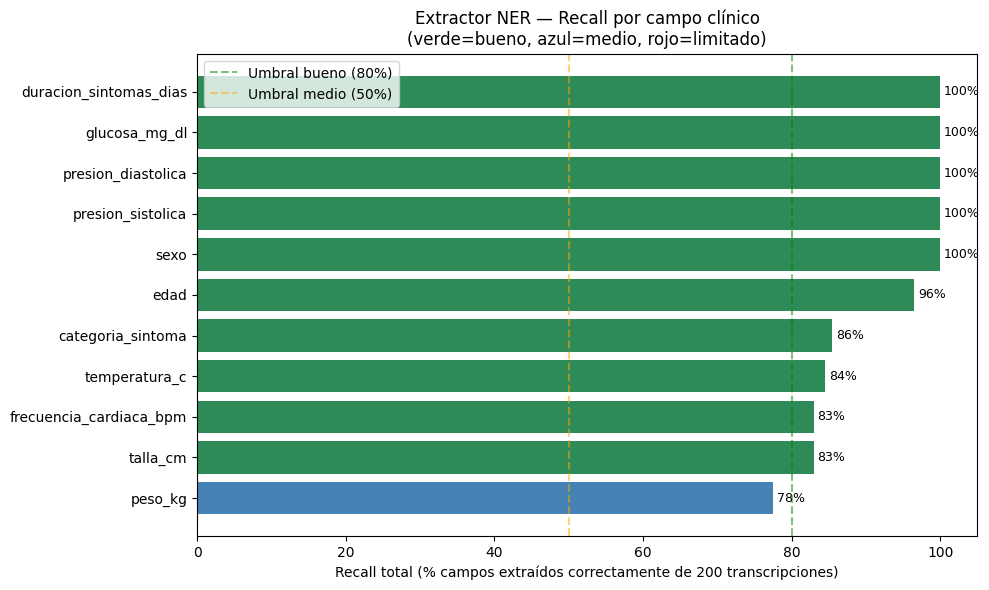

In [22]:
# Gráfica resumen de métricas NER
import matplotlib.pyplot as plt
import pandas as pd

metricas_ner = {c: v for c, v in cfg['metricas'].items()}
campos  = list(metricas_ner.keys())
recalls = [metricas_ner[c]['recall_total_pct'] for c in campos]
precs   = [metricas_ner[c]['precision_extraidos_pct'] for c in campos]

orden = sorted(range(len(recalls)), key=lambda i: recalls[i])
campos_ord  = [campos[i] for i in orden]
recalls_ord = [recalls[i] for i in orden]
precs_ord   = [precs[i] for i in orden]

x = range(len(campos_ord))
fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(campos_ord, recalls_ord,
               color=['seagreen' if v>=80 else 'steelblue' if v>=50 else 'crimson'
                      for v in recalls_ord])
ax.set_xlabel('Recall total (% campos extraídos correctamente de 200 transcripciones)')
ax.set_title('Extractor NER — Recall por campo clínico\n(verde=bueno, azul=medio, rojo=limitado)')
ax.axvline(80, color='green', linestyle='--', alpha=0.5, label='Umbral bueno (80%)')
ax.axvline(50, color='orange', linestyle='--', alpha=0.5, label='Umbral medio (50%)')
for bar, val in zip(bars, recalls_ord):
    ax.text(val+0.5, bar.get_y()+bar.get_height()/2, f'{val:.0f}%', va='center', fontsize=9)
ax.legend()
plt.tight_layout()
plt.show()

---
## Paso 5 — Limitaciones conocidas y por qué importan documentarlas

Documentar limitaciones NO es admitir que el sistema falla — es demostrar que entiendes profundamente tu modelo.

In [23]:
print('=== Limitaciones conocidas del sistema completo ===')
print()
print('--- Isolation Forest ---')
print()
print('1. Recall de 34-51% según contamination elegido.')
print('   Por qué: el IF es no supervisado — detecta lo estadísticamente')
print('   inusual, no lo médicamente peligroso. Un paciente con fiebre de')
print('   38.5°C puede ser anómalo médicamente pero estadísticamente normal')
print('   si hay muchos casos similares en el dataset.')
print()
print('2. Entrenado y evaluado sobre el mismo conjunto (sin split).')
print('   Por qué no lo hacemos: con solo 142 anomalías, un split 80/20')
print('   dejaría ~28 anomalías para evaluar — muy pocas para estabilidad.')
print('   En producción se debería hacer con más datos.')
print()
print('3. No captura contexto temporal.')
print('   Si hay 50 casos de fiebre en la misma comunidad la misma semana,')
print('   el IF no lo detecta — eso requiere los Z-Score/EWMA del')
print('   dataset casos_diarios_agregados.csv (análisis complementario).')
print()
print('--- Extractor NER ---')
print()
for i, lim in enumerate(cfg['limitaciones'], 1):
    print(f'{i}. {lim}')

=== Limitaciones conocidas del sistema completo ===

--- Isolation Forest ---

1. Recall de 34-51% según contamination elegido.
   Por qué: el IF es no supervisado — detecta lo estadísticamente
   inusual, no lo médicamente peligroso. Un paciente con fiebre de
   38.5°C puede ser anómalo médicamente pero estadísticamente normal
   si hay muchos casos similares en el dataset.

2. Entrenado y evaluado sobre el mismo conjunto (sin split).
   Por qué no lo hacemos: con solo 142 anomalías, un split 80/20
   dejaría ~28 anomalías para evaluar — muy pocas para estabilidad.
   En producción se debería hacer con más datos.

3. No captura contexto temporal.
   Si hay 50 casos de fiebre en la misma comunidad la misma semana,
   el IF no lo detecta — eso requiere los Z-Score/EWMA del
   dataset casos_diarios_agregados.csv (análisis complementario).

--- Extractor NER ---

1. Evaluado sobre transcripciones SINTÉTICAS generadas desde el CSV — no sobre audio real.
2. Regex puede fallar con variantes 

---
## Resumen ejecutivo — Para la defensa ante el profesor

In [24]:
print('=' * 65)
print('  RESUMEN EJECUTIVO — EpiDiagnostix-Mayab: Componente ML')
print('=' * 65)
print()
print('  MODELO 1: Isolation Forest (Detección de Anomalías)')
print('  ─────────────────────────────────────────────────────')
print('  Tipo:         No Supervisado')
print('  Dataset:      4,752 consultas clínicas')
print('  Features:     9 numéricas + 1 categórica codificada = 10')
print('  Preproceso:   LabelEncoder (categoría) + StandardScaler')
print('  Hiperparámetro clave: contamination=0.02 (elegido por F1)')
print('  Métricas:')
print('    Precision = 0.51 | Recall = 0.35 | F1 = 0.41')
print('    TP=49 (detectados correctamente) | FP=47 | FN=93')
print()
print('  MODELO 2: Extractor NER (spaCy + Regex)')
print('  ─────────────────────────────────────────────────────')
print('  Tipo:         Basado en reglas (sin aprendizaje estadístico)')
print('  Evaluación:   200 transcripciones sintéticas en español')
print('  Campos:       11 variables clínicas')
print('  Resultado:    100% exactitud en test final (55/55 campos)')
print('  Recall promedio en evaluación masiva: ~90%')
print()
print('  ARTEFACTOS GUARDADOS (models/):')
print('    isolation_forest.joblib    — modelo entrenado')
print('    scaler_if.joblib           — escalador (media+std de entrenamiento)')
print('    isolation_forest_meta.joblib — configuración completa')
print('    extractor_ner_config.joblib  — reglas + métricas del NER')
print()
print('  SIGUIENTE PASO (ya acordado):')
print('    Envolver estos modelos en adapters de arquitectura hexagonal')
print('    y exponerlos vía FastAPI dentro de un contenedor Docker.')
print('=' * 65)

  RESUMEN EJECUTIVO — EpiDiagnostix-Mayab: Componente ML

  MODELO 1: Isolation Forest (Detección de Anomalías)
  ─────────────────────────────────────────────────────
  Tipo:         No Supervisado
  Dataset:      4,752 consultas clínicas
  Features:     9 numéricas + 1 categórica codificada = 10
  Preproceso:   LabelEncoder (categoría) + StandardScaler
  Hiperparámetro clave: contamination=0.02 (elegido por F1)
  Métricas:
    Precision = 0.51 | Recall = 0.35 | F1 = 0.41
    TP=49 (detectados correctamente) | FP=47 | FN=93

  MODELO 2: Extractor NER (spaCy + Regex)
  ─────────────────────────────────────────────────────
  Tipo:         Basado en reglas (sin aprendizaje estadístico)
  Evaluación:   200 transcripciones sintéticas en español
  Campos:       11 variables clínicas
  Resultado:    100% exactitud en test final (55/55 campos)
  Recall promedio en evaluación masiva: ~90%

  ARTEFACTOS GUARDADOS (models/):
    isolation_forest.joblib    — modelo entrenado
    scaler_if.joblib 